# **Trabajo Práctico N°1: Modelo predictivo de tarifas de Uber**

  
**Integrantes:** Calabozo, Lapolla, Speranza  
**Cátedra:** TUIA-AA1 — 2025

---

## Introduccion y descripción del Dataset

El objetivo de este trabajo es **predecir las tarifas de Uber** utilizando técnicas de regresión lineal múltiple. Analizaremos un dataset que contiene información sobre viajes de Uber en Nueva York, incluyendo las siguientes variables.

### Variables del Dataset:
- **key:** Identificador único del viaje
- **fare_amount:** Tarifa del viaje (variable objetivo a predecir) 
- **pickup_datetime:** Fecha y hora de inicio del viaje
- **pickup_longitude, pickup_latitude:** Coordenadas del punto de origen
- **dropoff_longitude, dropoff_latitude:** Coordenadas del punto de destino
- **passenger_count:** Número de pasajeros


### Consideraciones importantes:
- Las coordenadas geográficas nos permitirán calcular la distancia del viaje
- La información temporal (fecha/hora) puede revelar patrones de demanda
- Es necesario limpiar datos atípicos y manejar valores faltantes

In [81]:
# Cargamos Librerías
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from pandas.plotting import scatter_matrix 

import warnings
warnings.filterwarnings('ignore')

## 2. Carga y Exploración Inicial de Datos

En esta sección cargamos los datos y realizamos una primera exploración para entender la estructura del dataset.

In [82]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'
df = pd.read_csv(file_path)

In [83]:
# Tabla con los tipos de datos
tipo = pd.DataFrame({
    'Columnas': df.columns,
    'Tipo de dato': df.dtypes
})

tipo[['Columnas', 'Tipo de dato']]

,Columnas,Tipo de dato
key,key,int64
date,date,object
fare_amount,fare_amount,float64
pickup_datetime,pickup_datetime,object
pickup_longitude,pickup_longitude,float64
pickup_latitude,pickup_latitude,float64
dropoff_longitude,dropoff_longitude,float64
dropoff_latitude,dropoff_latitude,float64
passenger_count,passenger_count,int64


In [84]:
# Información del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [85]:
# Primeras filas del DataFrame
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [86]:
# Estadísticas descriptivas del DataFrame
df.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


## 3. Análisis Descriptivo

En esta sección realizamos un análisis exhaustivo de los datos para comprender el comportamiento de cada variable y las relaciones entre ellas.

### 3.1 Distribución de Variables

Analizamos la distribución de cada variable para identificar patrones, outliers y características importantes utilizando boxplots.

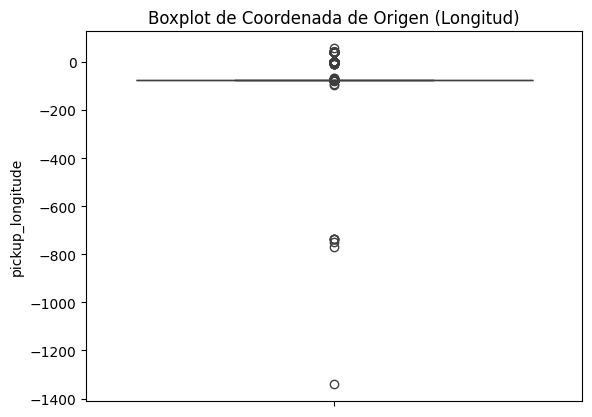

In [87]:
sns.boxplot(df['pickup_longitude'])
plt.title('Boxplot de Coordenada de Origen (Longitud)')
plt.show()

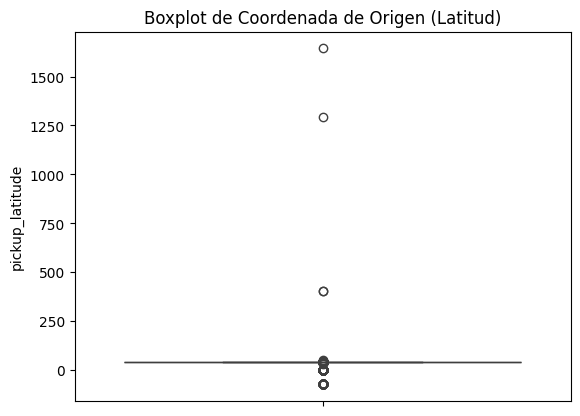

In [88]:
sns.boxplot(df['pickup_latitude'])
plt.title('Boxplot de Coordenada de Origen (Latitud)')
plt.show()

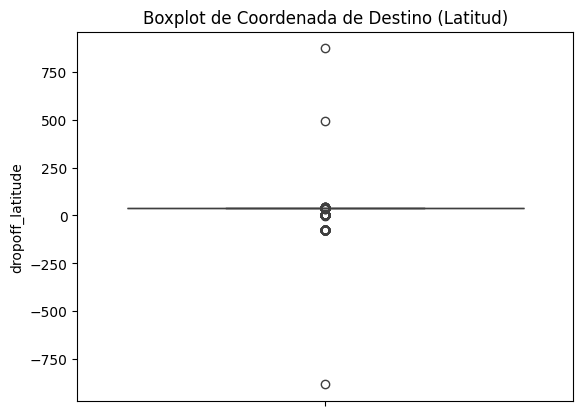

In [89]:
sns.boxplot(df['dropoff_latitude'])
plt.title('Boxplot de Coordenada de Destino (Latitud)')
plt.show()

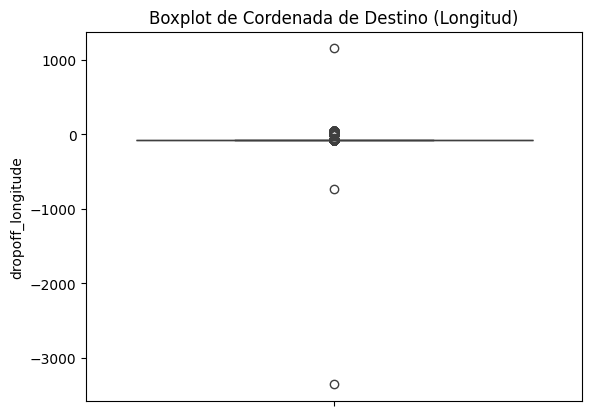

In [90]:
sns.boxplot(df['dropoff_longitude'])
plt.title('Boxplot de Cordenada de Destino (Longitud)')
plt.show()

Observamos que los valores de latitud y longitud posibles están dados por un rango [-90, +90 ] para la latitud y [-180, +180] para la longitud. Cualquier valor que salga del rango no corresponde a una coordenada válida.

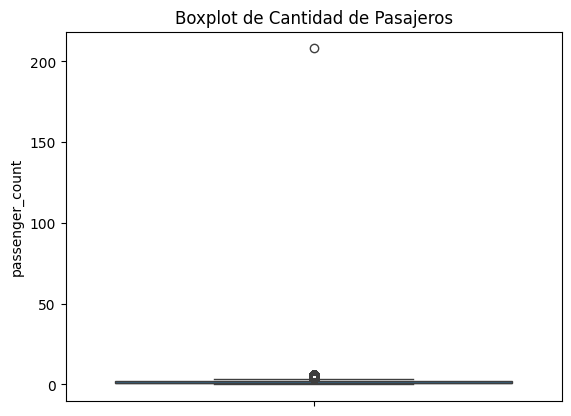

In [91]:
sns.boxplot(df['passenger_count'])
plt.title('Boxplot de Cantidad de Pasajeros')
plt.show()

La máxima capacidad de pasajeros que puede haber en un Uber es de 6 personas, pidiendo un UberXL.
La mínima cantidad de pasajeros es 0 puesto que se puede tratar de un UberEats o courier.
Hechas estas aclaraciones cualquier otro valor de la variables 'passenger_count' no es válido.

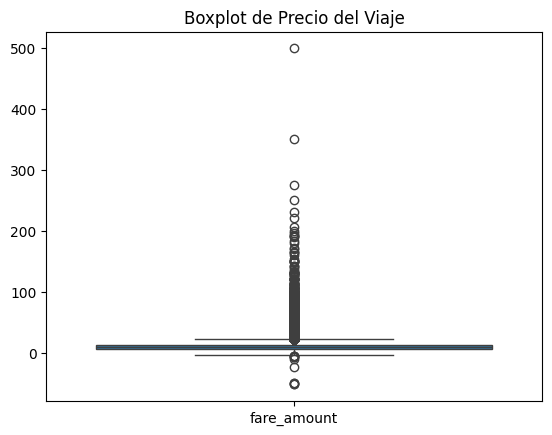

In [92]:
sns.boxplot(df[['fare_amount']])
plt.title('Boxplot de Precio del Viaje')
plt.show()

Podemos observar que hay valores de la variable 'fare_amount' negativos o cero. Si bien esto podría ser posible como no se tiene información respecto a cancelaciones o reintegros de los viajes no podemos asegurar que sean valores válidos. Si tuviesemos dos registros con el mismo valor de key podríamos observar si se corresponden los montos, que al sumarlos deberían de dar cero en caso de reembolso. Como no tenemos keys duplicados no podemos hacer esa conclusión.

In [93]:
print(f"Cantidad de llaves únicas: {len(df['key'].unique())}")
print(f"Tamaño del dataframe: {len(df)}")
print("Como los valores son iguales no tenemos claves duplicadas")

Cantidad de llaves únicas: 200000
Tamaño del dataframe: 200000
Como los valores son iguales no tenemos claves duplicadas


### 3.2 Respresentacion de datos no validos para la toma de decisiones 
En esta seccion analizamos tablas y métricas que resumen la cantidad y porcentaje de datos no válidos detectados en el dataset, fundamentales para decidir sobre su tratamiento

La ciudad es extensa y abarca varios barrios (Manhattan, Brooklyn, Queens, Bronx, Staten Island) Para contemplar esto se define un bounding box que incluya toda el área metropolitana con el siguiente rango: Latitud: 40.49 a 40.92 Longitud: -74.26 a -73.70 Según lo visto este rango incluye desde el extremo sur de Staten Island hasta el norte del Bronx, y desde el río Hudson hasta el límite este de Queens.

In [94]:
# Inicio de viaje fuera de coordenadas
print(f"La cantidad de coordenadas de inicio no válidas es de: {len(df[((df['pickup_latitude'] < 40.49) | (df['pickup_latitude'] > 40.92) | ((df['pickup_longitude'] > -73.70) | (df['pickup_longitude'] < -74.26)))])}")
print(f"Lo cual representa un {len(df[((df['pickup_latitude'] < 40.49) | (df['pickup_latitude'] > 40.92) | ((df['pickup_longitude'] > -73.70) | (df['pickup_longitude'] < -74.26)))]) / len(df) * 100}% del total de datos")

La cantidad de coordenadas de inicio no válidas es de: 4157
Lo cual representa un 2.0785% del total de datos


In [95]:
#Latitudes no validas
print(f"La cantidad de coordenadas no válidas (no son reales) es: {len(df[((((df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90)) | ((df['dropoff_latitude'] < -90) | (df['dropoff_latitude'] > 90)))) | (((df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180)) | ((df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180)))])}")
print(f"Lo cual representa un {len(df[((((df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90)) | ((df['dropoff_latitude'] < -90) | (df['dropoff_latitude'] > 90)))) | (((df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180)) | ((df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180)))]) / len(df) * 100}% de los datos")


La cantidad de coordenadas no válidas (no son reales) es: 12
Lo cual representa un 0.006% de los datos


In [96]:
# Cantidad de pasajeros no validos
print(f"La cantidad de viajes con cantidad de pasajeros invalida es: {len(df[df['passenger_count'] > 6])}")
print(f"Lo cual representa un {len(df[df['passenger_count'] > 6]) / len(df) * 100}% de los datos")

La cantidad de viajes con cantidad de pasajeros invalida es: 1
Lo cual representa un 0.0005% de los datos


In [97]:
# Costo de viajes no validos
print(f"La cantidad de viajes con costos no validos es de: {len(df[df['fare_amount'] <= 0])}")
print(f"Lo cual representa un {len(df[df['fare_amount'] <= 0]) / len(df) * 100}% de los datos")

La cantidad de viajes con costos no validos es de: 22
Lo cual representa un 0.011000000000000001% de los datos


### 3.3 Tratamiento de valores atipicos


En esta sección se realiza el tratamiento de los valores atípicos detectados en el análisis previo. Se eliminaron del dataset aquellas filas que presentan:

- Coordenadas geográficas fuera de los rangos válidos para latitud y longitud.

- Cantidad de pasajeros mayor a 6.

- Tarifas menores o iguales a 0.

- Distancias de viaje menores a 0.1 km o mayores a 100 km (estas se imputan como NaN para su posterior tratamiento).

In [98]:
#Coordenadas que no están dentro del rango latitud [-90,90], longitud [-180,180]
coordenadas_invalidas = df[((((df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90)) | ((df['dropoff_latitude'] < -90) | (df['dropoff_latitude'] > 90)))) | (((df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180)) | ((df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180)))].index

In [99]:
#Se eliminan las filas con coordenadas inválidas
df.drop(coordenadas_invalidas, inplace = True)
print(len(df))

199988


In [100]:
#Observarmos que hay un passenger_count con valor 208, lo reemplazamos por el valor máximo que no es outlier
passenger_invalido = df[df['passenger_count'] > 6].index
df.loc[passenger_invalido, 'passenger_count'] = 6

In [101]:
#Obtenemos los índices donde las tarifas son negativas o cero
fare_invalido = df[df['fare_amount'] <= 0].index

In [102]:
#Eliminamos las filas mediante los indices previamente obtenidos
df.drop(fare_invalido, inplace = True)
print(len(df))

199966


### 3.4 Ingeniería de Características (Feature Engineering)

Creamos nuevas variables para mejorar el poder predictivo del modelo:

In [103]:
def haversine(row: pd.DataFrame):
    '''
    Función que toma una fila del dataframe para calcular la distancia en kilometros entre dos coordenadas (origen y destino)
    utilizando la formula de haversine
    '''
    #Corresponde a el radio de la tierra aproximadamente
    R = 6371.0

    #Recibimos una fila del dataframe y calculamos los valores de la coordenada en radianes
    lat1_rad = np.radians(row['pickup_latitude'])
    lon1_rad = np.radians(row['pickup_longitude'])
    lat2_rad = np.radians(row['dropoff_latitude'])
    lon2_rad = np.radians(row['dropoff_longitude'])

    dif_lat = lat2_rad - lat1_rad
    dif_lon = lon2_rad - lon1_rad

    # Fórmula de Haversine para calcular distancia entre dos puntos
    a = np.sin(dif_lat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dif_lon / 2) ** 2
    c = 2 * np.asin(np.sqrt(a))

    # Distancia final
    distance = R * c
    return distance

#Aplicamos la función a cada fila del dataframe
df['distancia_km'] = df.apply(haversine, axis=1)

In [104]:
#Consideramos que un viaje menor a 0.1km y mayor a 100 km es inválido. 
#100km: Dos veces la distancia de los puntos más al norte y al sur de Nueva York
#0.1km: Los viajes deben realizar al menos una cuadra
df['distancia_km'][(df['distancia_km']<0.1) | (df['distancia_km'] > 100)] = np.nan

In [105]:
#Constantamos que date y pickup_datetime son iguales, comparandolas en el mismo formato
df["date"] = pd.to_datetime(df["date"]).dt.date
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"]).dt.date

(df["date"] == df["pickup_datetime"]).all() #Nos devuelve True, por lo que podemos eliminar la columna date

np.True_

In [106]:
#Eliminacion de columnas
#Key: Se condice con el índice nativo de pandas porque es un identificador único
#Pickup_datetime: Se condice uno a uno con date, sin presición de milísegundos
df = df.drop(labels=['key', 'pickup_datetime'], axis=1)

In [107]:
#Convertimos el campo 'date' del dataframe a datetime para poder extraer más features
fechas = pd.to_datetime(df['date'])

#Extraemos las horas y los días de la semana y realizamos una codificación cíclica para evitar el exceso de dummies
df['hora_sin'] = np.round(np.sin(2 * np.pi * (fechas.dt.hour / 24)),6)
df['hora_cos'] = np.round(np.cos(2 * np.pi * (fechas.dt.hour / 24)),6)
df['dia_semana_sin'] = np.sin(2 * np.pi * fechas.dt.day_of_week / 7)
df['dia_semana_cos'] = np.cos(2 * np.pi * fechas.dt.day_of_week / 7)

In [108]:
def pasajeros(pasajero: int):
    '''
    Función que toma un valor de la columna 'passenger_count' y lo convierte a la categoría segmentada
    '''
    if pasajero == 0:
        return "Cadetería"
    elif 1 <= pasajero <= 4:
        return "Uber"
    elif 5 <= pasajero <= 6:
        return "UberXL"
    
df['categoria_pasajeros'] = df['passenger_count'].apply(pasajeros)

Procedemos a convertir la columna 'passenger_count' en 3 categorias que representan los tipos de uber disponibles:
- Cadetería -> el viaje no posee pasajeros.
- Uber -> es un viaje en un auto regular con hasta 4 pasajeros.
- UberXL -> viaje en autos de mayor capacidad de pasajeros, hasta 6.

In [109]:
#Utilizamos el OneHotEncoder de sklearn para generar las dummies de las categorías antes mencionadas
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['categoria_pasajeros']])
nombres = ohe.get_feature_names_out()

dummies = pd.DataFrame(data = encoded, columns = nombres, index=df.index)
#Se elimina una de las categorías para cumplir con el requisito de One Hot Encoding, el caso base elegido es UberXL
dummies = dummies.drop(columns="categoria_pasajeros_UberXL", axis=1)

df['Cadeteria'] = dummies['categoria_pasajeros_Cadetería']
df['Uber'] = dummies['categoria_pasajeros_Uber']

### 3.5 Matriz de Correlación

Analizamos las correlaciones entre variables numéricas

In [110]:
#Separamos las variables numéricas
atributos = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", 'distancia_km'] 

<Axes: >

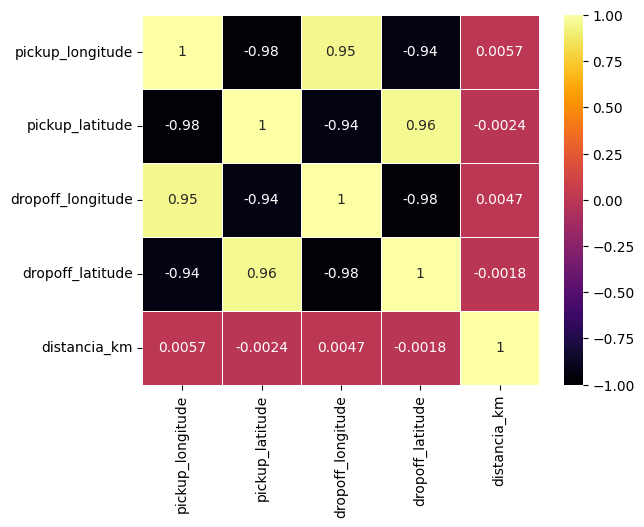

In [111]:
#Realizamos un heatmap utilizando la correlación de Pearson
sns.heatmap(data = df[atributos].corr(method='pearson'), vmax = 1, vmin = -1, cmap = 'inferno', annot = True, linewidths=.5)

## División Train-Test y Escalado de Datos

En esta sección se divide el dataset en conjuntos de entrenamiento y prueba, se imputan valores faltantes en la variable de distancia y se realiza el escalado de las variables numéricas para mejorar el desempeño de los modelos de regresión.

In [113]:
# Realizamos la división entre train y test, utilizando el 20% del dataframe para test.
# Seteamos una semilla para que el comportamiento sea siempre el mismo
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='fare_amount'), df['fare_amount'], test_size=0.2, random_state=42)

In [114]:
#Realizamos el escalado por Z-score porque concluimos que al filtrar las distancias menores a 0.1 y mayores a 100
#estamos reduciendo la cantidad de outliers, mitigando así la sensibilidad a los outliers del mismo.
X_standardScaler = StandardScaler()
#Entrenamos al Scaler con las distancias dataframe de training
X_train['distancia_km'] = X_standardScaler.fit_transform(X_train[['distancia_km']])
#Lo utilizamos para escalar los valores de distancia en test
X_test['distancia_km'] = X_standardScaler.transform(X_test[['distancia_km']])

#Realizamos el mismo proceso para los dataframes que contienen la variable target
Y_standardScaler = StandardScaler()
#Se utiliza reshape porque los métodos fit_transform y transform esperan una matriz 2D (n,1)
y_train_escalado = Y_standardScaler.fit_transform(np.array(y_train).reshape(-1, 1))
y_test_escalado = Y_standardScaler.transform(np.array(y_test).reshape(-1, 1))

In [115]:
#Realizamos la imputación de las distancias utilizando KNNImputer de SKLearn
knn = KNNImputer(n_neighbors=10)
#Lo entrenamos con nuestro dataframe de training
X_train['distancia_imputada'] = knn.fit_transform(X_train[['distancia_km']]) #type: ignore
#Y lo utilizamos para imputar también los valores de test faltantes
X_test['distancia_imputada'] = knn.transform(X_test[['distancia_km']]) 

## 4. Implementación de Regresión Lineal Múltiple

En esta sección implementamos un modelo de Regresión Lineal Múltiple para predecir la tarifa de los viajes de Uber. Se seleccionaron como variables predictoras aquellas que resultaron más relevantes tras el análisis exploratorio y la ingeniería de características:

- Distancia imputada del viaje (distancia_imputada)

- Variables cíclicas de hora y día de la semana (hora_sin, hora_cos, dia_semana_sin, dia_semana_cos)

- Variables dummy para la categoría de pasajeros (Uber, Cadeteria)

In [116]:
#Delimitamos las variables a nuestras variables categoricas codificadas y numéricas 
training_columns = ['distancia_imputada','hora_sin','hora_cos','dia_semana_sin', 'dia_semana_cos','Uber','Cadeteria'] 

In [117]:
#Realizamos el entrenamiento de nuestro modelo de regresión lineal con nuestro dataframe de training
ols = LinearRegression(fit_intercept=True)
model = ols.fit(X_train[training_columns], y_train)

In [118]:
#Realizamos las predicciones de tarifas en ambos set de datos de training y test
y_train_pred = model.predict(X_train[training_columns])
y_test_pred = model.predict(X_test[training_columns])

In [119]:
#Observamos en los coeficientes que la variable a la cual más peso le asigna el modelo de regresión lineal es la distancia
model.coef_

array([ 8.29430363e+00, -1.83186799e-15,  0.00000000e+00,  1.93084196e-01,
       -2.21419916e-01, -5.36935284e-02, -1.27169435e+00])

### 4.1 Análisis de Residuos - LinearRegression

Los residuos nos ayudan a evaluar si el modelo cumple los supuestos de la regresión lineal.

In [120]:
#Calculamos los residuos como la diferencia entre las tarifas reales escaladas y predichas en nuestro set de training 
df_x = pd.DataFrame(data = {'fare': y_train, 'predict': y_train_pred})
df_x['residuos'] = df_x['fare'] - df_x['predict']

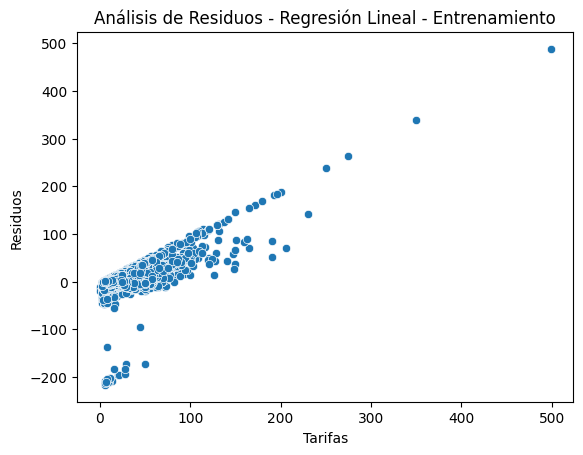

In [121]:
#Graficamos el comportamiento de los residuos en relacion a las tarifas escaladas
sns.scatterplot(x= df_x['fare'], y= df_x['residuos'])
plt.title('Análisis de Residuos - Regresión Lineal - Entrenamiento')
plt.xlabel('Tarifas')
plt.ylabel('Residuos')
plt.show()

El gráfico de residuos muestra que los errores no están distribuidos de manera completamente aleatoria alrededor de cero, sino que presentan cierta tendencia creciente a medida que aumentan las tarifas.
Podríamos decir a partir de nuestro gráfico de residuos que nuestro modelo tiende a estimar bien las tarifas bajas, pero presenta problemas a la hora de estimar tarifas altas. Podemos llegar a pensar que es probable que exista algun tipo de relación no lineal entre la variable target y las variables independientes.

In [122]:
#Obtenemos las métricas asociadas a nuestra regresión lineal en training
r2_lineal_train = r2_score(y_train, y_train_pred)
rmse_lineal_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Se tiene un R² de: {r2_lineal_train:.4f}")
print(f"Se tiene un MSE de: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"Se tiene un RMSE de: {rmse_lineal_train:.4f} dólares")
print(f"Se tiene un MAE de: {mean_absolute_error(y_train, y_train_pred):.4f} dólares")

Se tiene un R² de: 0.6694
Se tiene un MSE de: 32.7341
Se tiene un RMSE de: 5.7214 dólares
Se tiene un MAE de: 2.5464 dólares


In [123]:
#Calculamos los residuos como la diferencia entre las tarifas reales escaladas y predichas en nuestro set de test 
df_y = pd.DataFrame(data = {'fare': y_test, 'predict': y_test_pred})
df_y['residuos'] = df_y['fare'] - df_y['predict']

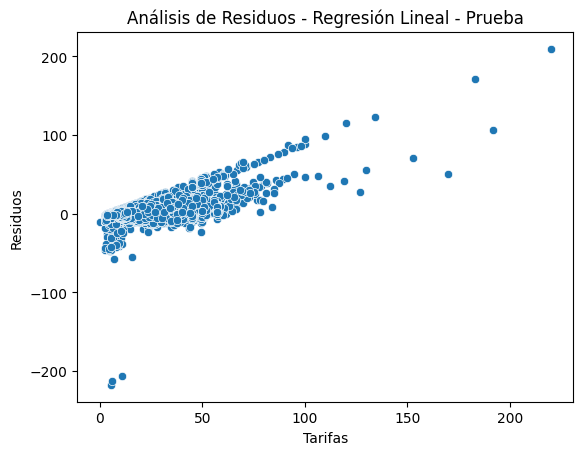

In [124]:
#Graficamos el comportamiento de los residuos en relacion a las tarifas escaladas
sns.scatterplot(x= df_y['fare'], y= df_y['residuos'])
plt.title('Análisis de Residuos - Regresión Lineal - Prueba')
plt.xlabel('Tarifas')
plt.ylabel('Residuos')
plt.show()

Podemos observar que los residuos se comportan de manera similar tanto en training como en test, reforzando así la idea de la existencia de una relacion no lineal y, a su vez, que nuestro modelo no está sobreajustado ya que mantiene la misma dispersión y tendencia creciente. 

In [125]:
#Calculamos las métricas para nuestro set de test
r2_lineal_test = r2_score(y_test, y_test_pred)
rmse_lineal_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Se tiene un R² de: {r2_lineal_test:.4f}")
print(f"Se tiene un MSE de: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"Se tiene un RMSE de: {rmse_lineal_test:.4f} dólares")
print(f"Se tiene un MAE de: {mean_absolute_error(y_test, y_test_pred):.4f} dólares")

Se tiene un R² de: 0.6793
Se tiene un MSE de: 30.0507
Se tiene un RMSE de: 5.4818 dólares
Se tiene un MAE de: 2.5645 dólares


El modelo de regresión lineal implementado según nuestro R² explica el 66,9% de la varianza de la variable target en nuestros datos de training y el 67.9% de los datos de test. Esta pequeña mejora en el valor de R² sugiere que nuestro modelo no esta realizando overfitting.

## Métodos de Gradiente Descendente

Implementamos los tres métodos de gradiente descendente para comparar su comportamiento:

In [126]:
#Implementamos la función de gradiente descendiente
def gradient_descent(X_train, y_train, X_val, y_val, lr = 0.01, epochs= 100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]
    
    o = X_val.shape[0]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))
    
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = [] 
    test_errors = []

    for _ in range(epochs):
        prediction_train = np.matmul(X_train, W) 
        error_train = y_train - prediction_train  
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        prediction_test = np.matmul(X_val, W) 
        error_test = y_val - prediction_test 
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum 
        gradient = np.transpose(grad_mul).reshape(-1, 1)

        W = W - (lr * gradient)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    plt.show()

    return W

In [127]:
#Adecuamos los dataframes a el formato requerido por la función de gradiente descendiente
X_train_grad = X_train[training_columns].values #(nxm)
y_train_grad = y_train_escalado #(nx1)
X_test_grad = X_test[training_columns].values#(pxm)
y_test_grad = y_test_escalado #(px1)

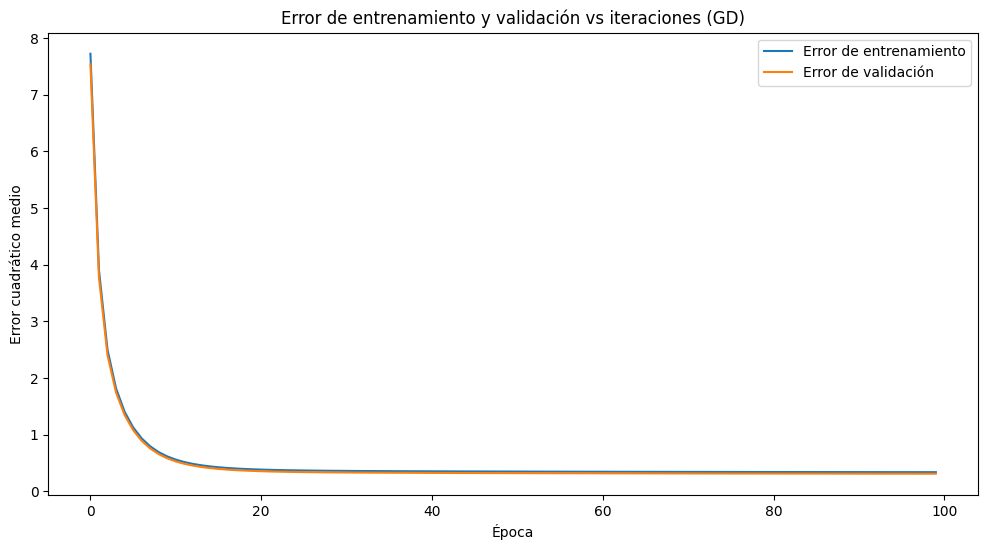

In [128]:
#Obtenemos los coeficientes obtenidos por el método de gradiente descendiente
#Utilizamos una taza de aprendizaje del 0.09 para lograr la convergencia y reducir el tiempo de ejecución
coef_gd = gradient_descent(X_train_grad, y_train_grad, X_test_grad, y_test_grad, lr = 0.09, epochs= 100)

Al inicio, ambos errores son elevados porque el modelo aún no ha ajustado sus parámetros.
Conforme avanzan las épocas, el error de entrenamiento desciende de forma continua ya que el modelo va “aprendiendo” a ajustar sus predicciones a los datos de entrenamiento.
El error de validación sigue un comportamiento muy similar al de entrenamiento, lo que sugiere buena capacidad de generalización.

In [129]:
#Definimos una formula para poder obtener las predicciones de la variable target
#en torno a los coeficientes obtenidos por los métodos de gradiente
def prediccion(coeficientes: np.ndarray, row: pd.DataFrame):
    coeficientes = coeficientes.flatten()
    reg = coeficientes[0] + coeficientes[1] * row['distancia_imputada'] + coeficientes[2] * row['hora_sin'] + coeficientes[3] *row['hora_cos'] + coeficientes[4] *row['dia_semana_sin'] + coeficientes[5] *row['dia_semana_cos'] + coeficientes[6] * row['Uber'] + coeficientes[7] * row['Cadeteria']
    return reg 

In [130]:
#Realizamos las predicciones en nuestro set de training y calculamos los residuos
pred_grad_train = X_train.apply(lambda x : prediccion(coef_gd, x), axis = 1)
pred_grad_train = pd.DataFrame(data = pred_grad_train, columns = ['Prediccion'])
pred_grad_train['tarifa'] = y_train_grad
pred_grad_train['residuos'] = pred_grad_train['tarifa'] - pred_grad_train['Prediccion']


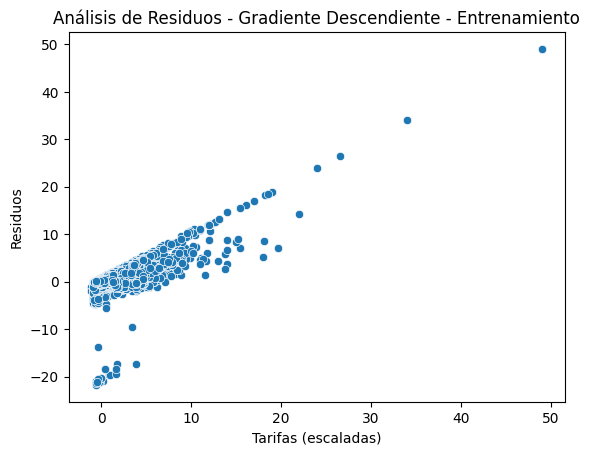

In [131]:
sns.scatterplot(x = pred_grad_train['tarifa'], y = pred_grad_train['residuos'])
plt.title('Análisis de Residuos - Gradiente Descendiente - Entrenamiento')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

En este gráfico de residuos del método de gradiente descendiente se observa un comportamiento similar al obtenido con el método de regresión lineal en entrenamiento. La única diferencia notable es que la variable target fue previamente escalada para mejorar el rendimiento de los métodos basados en gradiente. Como resultado, tanto la escala de las tarifas como el rango de los residuos difieren con respecto al gráfico del método de regresión lineal.

In [132]:
#Realizamos las predicciones en nuestro set de test y calculamos los residuos
pred_grad_test = X_test.apply(lambda x : prediccion(coef_gd, x), axis = 1)
pred_grad_test = pd.DataFrame(data = pred_grad_test, columns = ['Prediccion'])
pred_grad_test['tarifa'] = y_test_grad
pred_grad_test['residuos'] = pred_grad_test['tarifa'] - pred_grad_test['Prediccion']

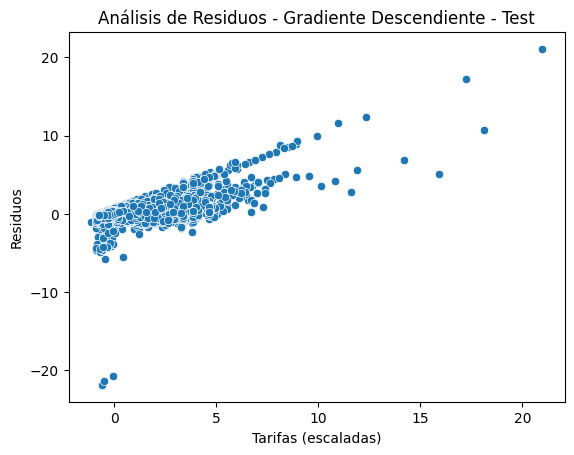

In [133]:
sns.scatterplot(x = pred_grad_test['tarifa'], y = pred_grad_test['residuos'])
plt.title('Análisis de Residuos - Gradiente Descendiente - Test')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

In [134]:
#Cálculo de métricas de gradiente descendiente
#Metricas de entrenamiento
r2_grad_train = r2_score(y_train_grad, pred_grad_train['Prediccion'])
mse_grad_train = mean_squared_error(y_train_grad, pred_grad_train['Prediccion'])
rmse_grad_train = np.sqrt(mse_grad_train)
mae_grad_train = mean_absolute_error(y_train_grad, pred_grad_train['Prediccion'])
print("- Método de gradiente descendiente -")
print("\n- Métricas de Entrenamiento -")
print(f"Se tiene un R² de: {r2_grad_train:.4f}")
print(f"Se tiene un MSE de: {mse_grad_train:.4f}")
print(f"Se tiene un RMSE de: {rmse_grad_train:.4f}")
print(f"Se tiene un MAE de: {mae_grad_train:.4f}")

#Metricas de test
print("\n- Métricas de Test -")
r2_grad_test = r2_score(y_test_grad, pred_grad_test['Prediccion'])
mse_grad_test = mean_squared_error(y_test_grad, pred_grad_test['Prediccion'])
rmse_grad_test = np.sqrt(mse_grad_test)
mae_grad_test = mean_absolute_error(y_test_grad, pred_grad_test['Prediccion'])

print(f"Se tiene un R² de: {r2_grad_test:.4f}")
print(f"Se tiene un MSE de: {mse_grad_test:.4f}")
print(f"Se tiene un RMSE de: {rmse_grad_test:.4f}")
print(f"Se tiene un MAE de: {mae_grad_test:.4f}")

- Método de gradiente descendiente -

- Métricas de Entrenamiento -
Se tiene un R² de: 0.6640
Se tiene un MSE de: 0.3360
Se tiene un RMSE de: 0.5796
Se tiene un MAE de: 0.2636

- Métricas de Test -
Se tiene un R² de: 0.6739
Se tiene un MSE de: 0.3086
Se tiene un RMSE de: 0.5555
Se tiene un MAE de: 0.2652


In [135]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr = .01, epochs = 100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)

            

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.yticks()
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.ylim(0, 10000)
    plt.show()

    return W

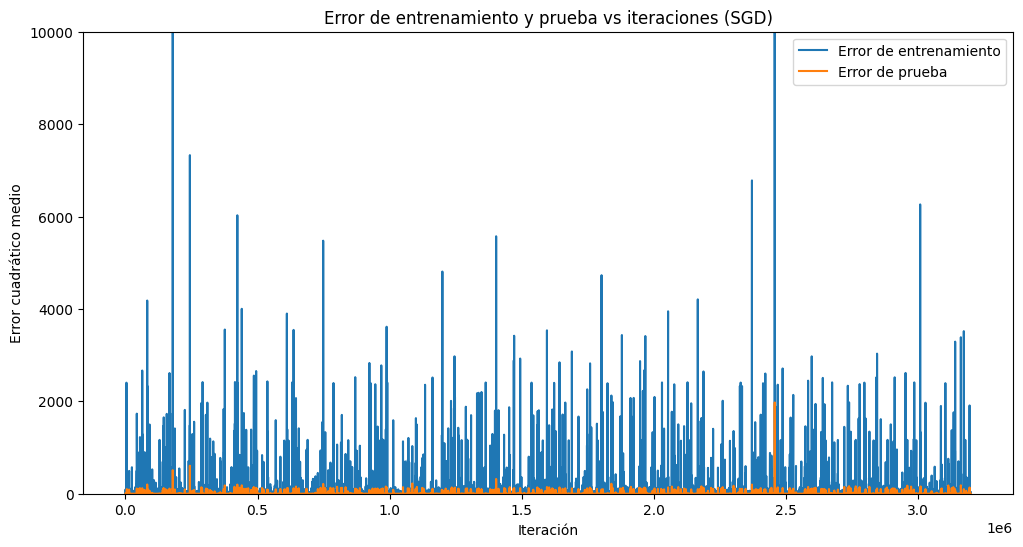

In [136]:
#Obtenemos los coeficientes del método de gradiente descendiente estocástico utilizando
#Learning Rate: 0.01
#Épocas: 20
coef_gde = stochastic_gradient_descent(X_train_grad, y_train_grad, X_test_grad, y_test_grad, lr = .01, epochs = 20)

Con el método de gradiente descendiente estocástico no logramos llegar a la convergencia en un tiempo aceptable. No pudimos interpretar la salida de manera correcta.

In [137]:
#Realizamos las predicciones en relación a los coeficientes obtenidos por el método de gradiente descendiente estocástico
#Entendemos que al no lograr una convergencia, no obtendremos métricas útiles al respecto
#Esperamos un desempeño pobre tanto en training como en test
pred_grad_estocastico_train = X_train.apply(lambda x: prediccion(coef_gde, x), axis=1)
pred_grad_estocastico_train = pd.DataFrame(data=pred_grad_estocastico_train, columns=['Prediccion'])
pred_grad_estocastico_train['tarifa'] = y_train_grad
pred_grad_estocastico_train['residuos'] = pred_grad_estocastico_train['tarifa'] - pred_grad_estocastico_train['Prediccion']

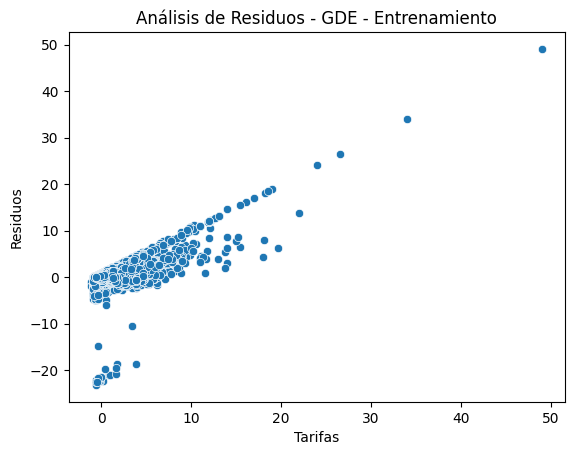

In [138]:
sns.scatterplot(x = pred_grad_estocastico_train['tarifa'], y = pred_grad_estocastico_train['residuos'])
plt.title('Análisis de Residuos - GDE - Entrenamiento')
plt.xlabel('Tarifas')
plt.ylabel('Residuos')
plt.show()

En este caso, los coeficientes obtenidos por el método de gradiente descendiente estocástico no nos permiten realizar predicciones buenas. Podemos observar que tanto para valores de tarifa bajos, como altos, realiza sobre-estimaciones.

In [139]:
#Realizamos las predicciones en nuestro set de test y calculamos los residuos
pred_grad_estocastico_test = X_test.apply(lambda x : prediccion(coef_gde, x), axis = 1)
pred_grad_estocastico_test = pd.DataFrame(data = pred_grad_estocastico_test, columns = ['Prediccion'])
pred_grad_estocastico_test['tarifa'] = y_test_grad
pred_grad_estocastico_test['residuos'] = pred_grad_estocastico_test['tarifa'] - pred_grad_estocastico_test['Prediccion']

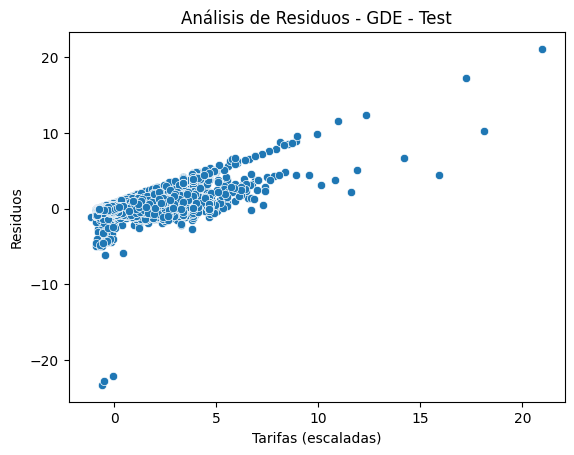

In [140]:
sns.scatterplot(x = pred_grad_estocastico_test['tarifa'], y = pred_grad_estocastico_test['residuos'])
plt.title('Análisis de Residuos - GDE - Test')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

Esperamos el mismo comportamiento por parte del gráfico de residuos del test.

In [141]:
#Cálculo de métricas de gradiente descendiente estocástico
#Metricas de entrenamiento

r2_estocastico_train = r2_score(y_train_grad, pred_grad_estocastico_train['Prediccion'])
mse_estocastico_train = mean_squared_error(y_train_grad, pred_grad_estocastico_train['Prediccion'])
rmse_estocastico_train = np.sqrt(mse_estocastico_train)
mae_estocastico_train = mean_absolute_error(y_train_grad, pred_grad_estocastico_train['Prediccion'])
print("- Método de gradiente descendiente estocástico-")
print("\n- Métricas de entrenamiento -")
print(f"Se tiene un R² de: {r2_estocastico_train:.4f}")
print(f"Se tiene un MSE de: {mse_estocastico_train:.4f}")
print(f"Se tiene un RMSE de: {rmse_estocastico_train:.4f}")
print(f"Se tiene un MAE de: {mae_estocastico_train:.4f}")

#Metricas de test
r2_estocastico_test = r2_score(y_test_grad, pred_grad_estocastico_test['Prediccion'])
mse_estocastico_test = mean_squared_error(y_test_grad, pred_grad_estocastico_test['Prediccion'])
rmse_estocastico_test = np.sqrt(mse_estocastico_test)
mae_estocastico_test = mean_absolute_error(y_test_grad, pred_grad_estocastico_test['Prediccion'])
print("\n- Métricas de test -")
print(f"Se tiene un R² de: {r2_estocastico_test:.4f}")
print(f"Se tiene un MSE de: {mse_estocastico_test:.4f}")
print(f"Se tiene un RMSE de: {rmse_estocastico_test:.4f}")
print(f"Se tiene un MAE de: {mae_estocastico_test:.4f}")

- Método de gradiente descendiente estocástico-

- Métricas de entrenamiento -
Se tiene un R² de: 0.6656
Se tiene un MSE de: 0.3344
Se tiene un RMSE de: 0.5783
Se tiene un MAE de: 0.2477

- Métricas de test -
Se tiene un R² de: 0.6756
Se tiene un MSE de: 0.3069
Se tiene un RMSE de: 0.5540
Se tiene un MAE de: 0.2494


In [142]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr = 0.01, epochs = 100, batch_size = 11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

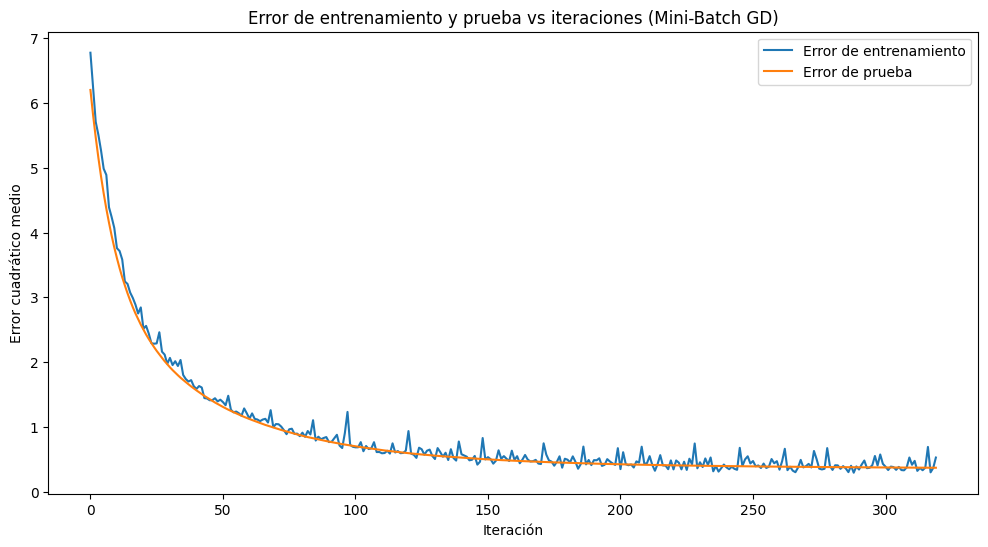

In [143]:
#Obtenemos los coeficientes del método de gradiente descendiente minibatch
#Utilizamos el learning rate provisto de 0.01
#Utilizamos un batch size de 10.000, lo que resultaría en aproximadamente 16 batches
#Utilizamos 20 épocas lo que resultaría en aproximadamente unas 320 iteraciones
coef_gdm = mini_batch_gradient_descent(X_train_grad, y_train_grad, X_test_grad, y_test_grad, lr = 0.01, epochs = 20, batch_size=10000)

El gráfico muestra que el error de entrenamiento y prueba disminuyen de manera estable con las iteraciones, alcanzando valores bajos y similares. Esto indica que el modelo converge correctamente y logra una buena generalización, sin sobreajustar.

In [144]:
#Realizamos las predicciones de las tarifas en nuestro dataset de training
pred_grad_minibatch_train = X_train.apply(lambda x : prediccion(coef_gdm, x), axis = 1)
pred_grad_minibatch_train = pd.DataFrame(data = pred_grad_minibatch_train, columns = ['Prediccion'])
pred_grad_minibatch_train['tarifa'] = y_train_grad
pred_grad_minibatch_train['residuos'] = pred_grad_minibatch_train['tarifa'] - pred_grad_minibatch_train['Prediccion']

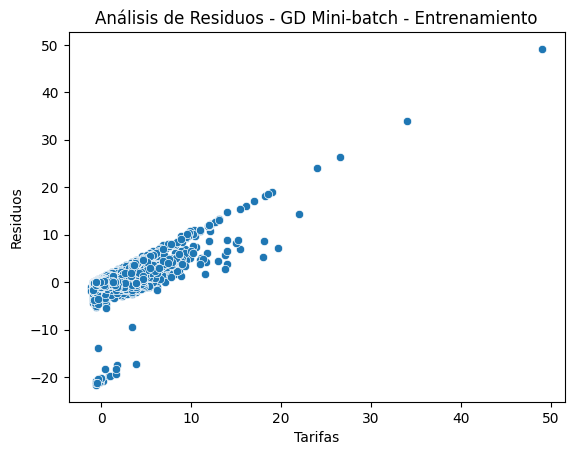

In [145]:
sns.scatterplot(x = pred_grad_minibatch_train['tarifa'], y = pred_grad_minibatch_train['residuos'])
plt.title('Análisis de Residuos - GD Mini-batch - Entrenamiento')
plt.xlabel('Tarifas')
plt.ylabel('Residuos')
plt.show()

Nuevamente observamos una tendencia y dispersión similar que los gráficos obtenidos en los métodos anteriores, salvo el estocástico.

In [146]:
#Realizamos las predicciones en nuestro set de test y calculamos los residuos
pred_grad_minibatch_test = X_test.apply(lambda x : prediccion(coef_gdm, x), axis = 1)
pred_grad_minibatch_test = pd.DataFrame(data = pred_grad_minibatch_test, columns = ['Prediccion'])
pred_grad_minibatch_test['tarifa'] = y_test_grad
pred_grad_minibatch_test['residuos'] = pred_grad_minibatch_test['tarifa'] - pred_grad_minibatch_test['Prediccion']

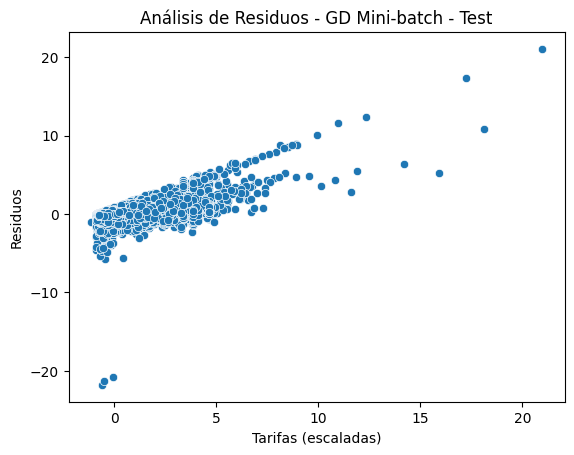

In [147]:
sns.scatterplot(x = pred_grad_minibatch_test['tarifa'], y = pred_grad_minibatch_test['residuos'])
plt.title('Análisis de Residuos - GD Mini-batch - Test')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

Observamos tendencia y dispersión similares al gráfico de training, podemos concluir de la misma manera que no hay sobreajuste y está generalizando correctamente.

In [148]:
#Métricas de minibatch
#Metricas de entrenamiento
r2_minibatch_train = r2_score(y_train_grad, pred_grad_minibatch_train['Prediccion'])
mse_minibatch_train = mean_squared_error(y_train_grad, pred_grad_minibatch_train['Prediccion'])
rmse_minibatch_train = np.sqrt(mse_minibatch_train)
mae_minibatch_train = mean_absolute_error(y_train_grad, pred_grad_minibatch_train['Prediccion'])

print("- Método de gradiente descendiente minibatch -")
print("\n- Métricas de entrenamiento -")
print(f"Se tiene un R² de: {r2_minibatch_train:.4f}")
print(f"Se tiene un MSE de: {mse_minibatch_train:.4f}")
print(f"Se tiene un RMSE de: {rmse_minibatch_train:.4f}")
print(f"Se tiene un MAE de: {mae_minibatch_train:.4f}")


#Metricas de test
r2_minibatch_test= r2_score(y_test_grad, pred_grad_minibatch_test['Prediccion'])
mse_minibatch_test = mean_squared_error(y_test_grad, pred_grad_minibatch_test['Prediccion'])
rmse_minibatch_test = np.sqrt(mse_minibatch_test)
mae_minibatch_test = mean_absolute_error(y_test_grad, pred_grad_minibatch_test['Prediccion'])
print("\n- Métricas de test -")
print(f"Se tiene un R² de: {r2_minibatch_test:.4f}")
print(f"Se tiene un MSE de: {mse_minibatch_test:.4f}")
print(f"Se tiene un RMSE de: {rmse_minibatch_test:.4f}")
print(f"Se tiene un MAE de: {mae_minibatch_test:.4f}")

- Método de gradiente descendiente minibatch -

- Métricas de entrenamiento -
Se tiene un R² de: 0.5996
Se tiene un MSE de: 0.4004
Se tiene un RMSE de: 0.6328
Se tiene un MAE de: 0.3091

- Métricas de test -
Se tiene un R² de: 0.6101
Se tiene un MSE de: 0.3689
Se tiene un RMSE de: 0.6073
Se tiene un MAE de: 0.3084


## Métodos de Regularización

Implementamos Lasso, Ridge y Elastic Net con diferentes valores de regularización:

In [149]:
#Para utilizar los métodos de regularización requerimos que nuestros set de training esten escalados,
#reutilizamos los ya obtenidos para los métodos anteriores 
X = X_train_grad
y = y_train_escalado

In [150]:
lassoCV = LassoCV(alphas = np.logspace(-3, 6, 200), fit_intercept = True)
ridgeCV =  RidgeCV(alphas = np.logspace(-3, 6, 200), fit_intercept = True, store_cv_results = True)
elasticnetCV = ElasticNetCV(alphas = np.logspace(-3, 6, 200), fit_intercept = True)

lassoCV.fit(X, y)
ridgeCV.fit(X, y)
elasticnetCV.fit(X,y)

print("\nCoeficientes del modelo Lasso:")
print(lassoCV.coef_)
print(lassoCV.score(X,y))

print("\nCoeficientes del modelo Ridge:")
print(ridgeCV.coef_)
print(ridgeCV.score(X,y))

print("\nCoeficientes del modelo ElasticNet:")
print(elasticnetCV.coef_)

print("\nR2 - ElasticNet:")
print(elasticnetCV.score(X,y))



Coeficientes del modelo Lasso:
[ 0.8324719   0.          0.          0.017347   -0.02021521 -0.
 -0.        ]
0.6693562949079386

Coeficientes del modelo Ridge:
[ 0.83339535  0.          0.          0.01939342 -0.02224351 -0.0051832
 -0.12247479]
0.6694186572282632

Coeficientes del modelo ElasticNet:
[ 0.83258389  0.          0.          0.01833436 -0.02122789 -0.
 -0.        ]

R2 - ElasticNet:
0.6693595293820878


In [151]:
y_train_pred_lasso = lassoCV.predict(X_train_grad)

r2_lasso = r2_score(y_train_grad, y_train_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_train_grad, y_train_pred_lasso))


print("--- Evaluación del Modelo Lasso (sobre datos de entrenamiento) ---")
print(f"R-cuadrado (R²): {r2_lasso:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_lasso:.4f}\n")

--- Evaluación del Modelo Lasso (sobre datos de entrenamiento) ---
R-cuadrado (R²): 0.6694
Raíz del Error Cuadrático Medio (RMSE): 0.5750



In [152]:
y_train_pred_ridge = ridgeCV.predict(X_train_grad)

r2_ridge = r2_score(y_train_grad, y_train_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_train_grad, y_train_pred_ridge))


print("--- Evaluación del Modelo Ridge (sobre datos de entrenamiento) ---")
print(f"R-cuadrado (R²): {r2_ridge:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_ridge:.4f}\n")

--- Evaluación del Modelo Ridge (sobre datos de entrenamiento) ---
R-cuadrado (R²): 0.6694
Raíz del Error Cuadrático Medio (RMSE): 0.5750



In [153]:
y_train_pred_elasticnet = elasticnetCV.predict(X_train_grad)

r2_elasticnet = r2_score(y_train_grad, y_train_pred_elasticnet)
rmse_elasticnet = np.sqrt(mean_squared_error(y_train_grad, y_train_pred_elasticnet))

print("--- Evaluación del Modelo ElasticNet (sobre datos de entrenamiento) ---")
print(f"R²: {r2_elasticnet:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_elasticnet:.4f}\n")

--- Evaluación del Modelo ElasticNet (sobre datos de entrenamiento) ---
R²: 0.6694
Raíz del Error Cuadrático Medio (RMSE): 0.5750



In [154]:
y_test_pred_lasso = lassoCV.predict(X_test_grad)
r2_test_lasso = r2_score(y_test_escalado, y_test_pred_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test_escalado, y_test_pred_lasso))

print("--- Evaluación de Lasso en test ---")
print(f"R²: {r2_test_lasso:.4f}")
print(f"RMSE: {rmse_test_lasso:.4f}")

--- Evaluación de Lasso en test ---
R²: 0.6792
RMSE: 0.5509


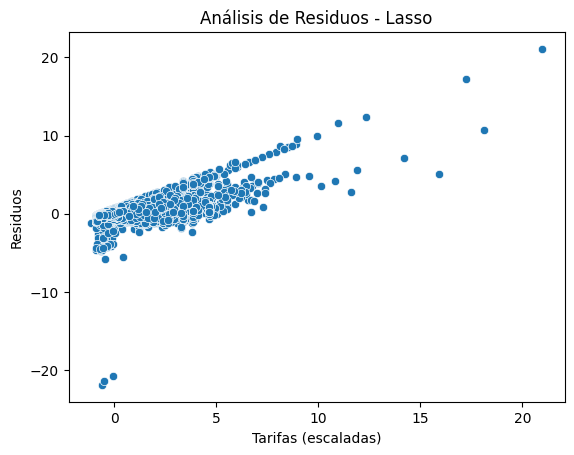

In [155]:
tarifa_real = y_test_escalado.flatten()
prediccion_lasso = y_test_pred_lasso.flatten()
data_para_df = {'tarifa': tarifa_real, 'prediccion': prediccion_lasso}
df_lasso = pd.DataFrame(data_para_df)
df_lasso['residuos'] = df_lasso['tarifa'] - df_lasso['prediccion']

sns.scatterplot(x = df_lasso['tarifa'], y = df_lasso['residuos'])
plt.title('Análisis de Residuos - Lasso')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

In [156]:
y_test_pred_ridge = ridgeCV.predict(X_test_grad)
r2_test_ridge = r2_score(y_test_escalado, y_test_pred_ridge)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test_escalado, y_test_pred_ridge))

print("--- Evaluación de Ridge en test ---")
print(f"R-cuadrado (R²): {r2_test_ridge:.4f}")
print(f"RMSE: {rmse_test_ridge:.4f}")


--- Evaluación de Ridge en test ---
R-cuadrado (R²): 0.6793
RMSE: 0.5509


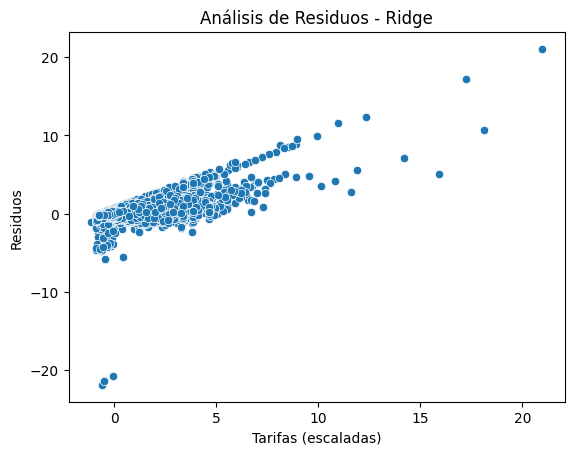

In [157]:
y_test_pred_ridge = ridgeCV.predict(X_test_grad)
tarifa_real = y_test_escalado.flatten()
prediccion_ridge = y_test_pred_ridge.flatten()
data_ridge_df = {'tarifa': tarifa_real, 'prediccion': prediccion_ridge}
df_ridge = pd.DataFrame(data_ridge_df)
df_ridge['residuos'] = df_ridge['tarifa'] - df_ridge['prediccion']

sns.scatterplot(x = df_ridge['tarifa'], y = df_ridge['residuos'])
plt.title('Análisis de Residuos - Ridge')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

In [158]:
y_test_pred_elasticnet = elasticnetCV.predict(X_test_grad)
r2_test_elasticnet = r2_score(y_test_escalado, y_test_pred_elasticnet)
rmse_test_elasticnet = np.sqrt(mean_squared_error(y_test_escalado, y_test_pred_elasticnet))

print("--- Evaluación de Ridge en test ---")
print(f"R-cuadrado (R²): {r2_test_elasticnet:.4f}")
print(f"RMSE: {rmse_test_elasticnet:.4f}")

--- Evaluación de Ridge en test ---
R-cuadrado (R²): 0.6792
RMSE: 0.5509


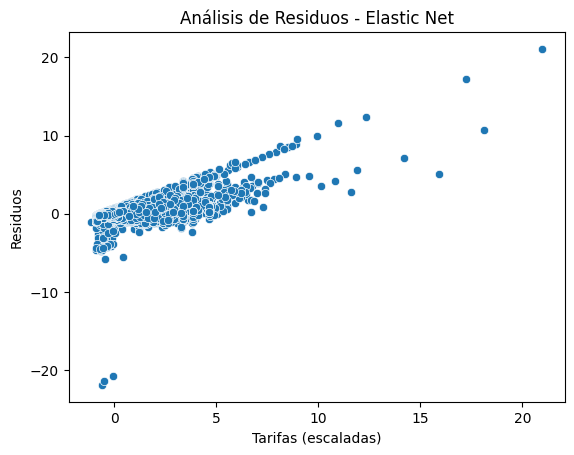

In [159]:
y_test_pred_elasticnet = elasticnetCV.predict(X_test_grad)
tarifa_real = y_test_escalado.flatten()
prediccion_elasticnet = y_test_pred_elasticnet.flatten()
data_elasticnet_df = {'tarifa': tarifa_real, 'prediccion': prediccion_elasticnet}
df_elasticnet = pd.DataFrame(data_elasticnet_df)
df_elasticnet['residuos'] = df_elasticnet['tarifa'] - df_elasticnet['prediccion']

sns.scatterplot(x = df_elasticnet['tarifa'], y = df_elasticnet['residuos'])
plt.title('Análisis de Residuos - Elastic Net')
plt.xlabel('Tarifas (escaladas)')
plt.ylabel('Residuos')
plt.show()

## Optimización de Hiperparámetros

Utilizamos técnicas de búsqueda sistemática para encontrar los mejores hiperparámetros para cada modelo.

**Metodo de Descenso de Gradiente:**

Para este método no hubo una gran variación en los hiperparámetros. Por suerte, al comienzo, al usar un learning rate de 0.1 y un número de epochs igual a 1000, se consiguió que tanto las curvas de error de entrenamiento como las de validación presentaran un descenso rápido en el error, lo que indica que el modelo capta patrones relevantes desde el inicio. Además, la tendencia es sostenida, por lo cual no parece haber overfitting.
Luego de esto, solo se realizó un pequeño ajuste en el learning rate para lograr que las curvas tuvieran un descenso más suave, lo cual se logró con un lr = 0.09, manteniendo epochs = 100.

**Metodo de Descenso de Gradiente Mini-Batch:**

Para este método se hizo variar el learning-rate (lr) por un rango de valores desde 0.01 hasta 0.000001, epocas de 5 hasta 50 y batch size de 8 hasta 10000. Estas variaciones de hiper parámetros daba lugar a graficos de 'loss vs epochs' en donde el error de prueba solia mantenerse cosntante o tenia una leve variación de error cuadrático medio y mientras esto sucedia el error de entrenamiente presentaba oscilaciones muy grandes debido al ruido introducido por cada lote. Luego de sucecivos cambios se llego a un lr = 0.01, epochs = 20 y un batch_size = 10000 en donde el error de prueba presenta una tendencia de descenso mucho más sueve y el error de entrenamiento presenta oscilaciones en un rango más aceptable.

**Metodo de Descenso de Gradiente Estocástico:**


En el caso de este método, se probó un amplio rango de valores para los hiperparámetros learning rate y epochs. Sin importar cuáles utilizáramos —desde lr = 0.1 hasta 0.000001, y epochs= 5 hasta 1000— no se logró que las curvas de error presentaran descensos significativos en el error cuadrático medio, ni una tendencia sostenida a lo largo de las iteraciones.

(No se probó un lr menor ni un número de epochs mayor debido a que el tiempo de ejecución superaba los 11 minutos y no presentaba mejoras relevantes).

**Métodos de Regularización**


Para optimizar los hiperparámetros de Lasso y Ridge, utilizamos las versiones con Cross-Validation (LassoCV y RidgeCV). Estas librerías no requieren que probemos manualmente distintos valores de α internamente prueban múltiples valores de α y seleccionan automáticamente el que minimiza el error promedio de validación cruzada.

Esto significa que la selección de α está optimizada de forma automática, buscando el balance entre ajustar bien los datos de entrenamiento y no sobreajustar (overfitting).

Como resultado, obtenemos los coeficientes y el R² del modelo ya ajustados al mejor α, sin necesidad de probar manualmente cada valor.

Observamos que Lasso tiende a reducir algunos coeficientes a cero, mientras que Ridge los ajusta sin eliminarlos, pero ambos aprovechan la optimización automática de 
α para lograr un buen desempeño predictivo.

## Comparación de Modelos

In [160]:
print("Métrica seleccionada: R-Cuadrado (porcentual)")
print("\n- Análisis en entrenamiento -")
print(f"Lineal: {r2_lineal_train*100:.2f}%")
print(f"Gradiente: {r2_grad_train*100:.2f}%")
print(f"Gradiente Estocástico: {r2_estocastico_train*100:.2f}%")
print(f"Gradiente Minibatch: {r2_minibatch_train*100:.2f}%")
print(f"Lasso: {r2_lasso*100:.2f}%  | alfa óptimo: {lassoCV.alpha_}")
print(f"Ridge: {r2_ridge*100:.2f}%  | alfa óptimo: {ridgeCV.alpha_}")
print(f"ElasticNet: {r2_elasticnet*100:.2f}%  | alfa: {elasticnetCV.alpha_}, l1_ratio: {elasticnetCV.l1_ratio_}")

print("\n- Análisis en test -")
print(f"Lineal: {r2_lineal_test*100:.2f}%")
print(f"Gradiente: {r2_grad_test*100:.2f}%")
print(f"Gradiente Estocástico: {r2_estocastico_test*100:.2f}%")
print(f"Gradiente Minibatch: {r2_minibatch_test*100:.2f}%")
print(f"Lasso: {r2_test_lasso*100:.2f}%")
print(f"Ridge: {r2_test_ridge*100:.2f}%")
print(f"ElasticNet: {r2_test_elasticnet*100:.2f}%")

Métrica seleccionada: R-Cuadrado (porcentual)

- Análisis en entrenamiento -
Lineal: 66.94%
Gradiente: 66.40%
Gradiente Estocástico: 66.56%
Gradiente Minibatch: 59.96%
Lasso: 66.94%  | alfa óptimo: 0.001
Ridge: 66.94%  | alfa óptimo: 24.37444150122222
ElasticNet: 66.94%  | alfa: 0.001, l1_ratio: 0.5

- Análisis en test -
Lineal: 67.93%
Gradiente: 67.39%
Gradiente Estocástico: 67.56%
Gradiente Minibatch: 61.01%
Lasso: 67.92%
Ridge: 67.93%
ElasticNet: 67.92%


In [161]:
print("Métrica seleccionada: RMSE")
print("\n- Análisis en entrenamiento -")
print(f"Lineal: {rmse_lineal_train:.4f}")
print(f"Gradiente: {rmse_grad_train:.4f}")
print(f"Gradiente Estocástico: {rmse_estocastico_train:.4f}")
print(f"Gradiente Minibatch: {rmse_minibatch_train:.4f}")
print(f"Lasso: {rmse_lasso:.4f}  | alfa óptimo: {lassoCV.alpha_}")
print(f"Ridge: {rmse_ridge:.4f}  | alfa óptimo: {ridgeCV.alpha_}")
print(f"ElasticNet: {rmse_elasticnet:.4f}  | alfa: {elasticnetCV.alpha_}, l1_ratio: {elasticnetCV.l1_ratio_}")

print("\n- Análisis en test -")
print(f"Lineal: {rmse_lineal_test:.4f}")
print(f"Gradiente: {rmse_grad_test:.4f}")
print(f"Gradiente Estocástico: {rmse_estocastico_test:.4f}")
print(f"Gradiente Minibatch: {rmse_minibatch_test:.4f}")
print(f"Lasso: {rmse_test_lasso:.4f}")
print(f"Ridge: {rmse_test_ridge:.4f}")
print(f"ElasticNet: {rmse_test_elasticnet:.4f}")

Métrica seleccionada: RMSE

- Análisis en entrenamiento -
Lineal: 5.7214
Gradiente: 0.5796
Gradiente Estocástico: 0.5783
Gradiente Minibatch: 0.6328
Lasso: 0.5750  | alfa óptimo: 0.001
Ridge: 0.5750  | alfa óptimo: 24.37444150122222
ElasticNet: 0.5750  | alfa: 0.001, l1_ratio: 0.5

- Análisis en test -
Lineal: 5.4818
Gradiente: 0.5555
Gradiente Estocástico: 0.5540
Gradiente Minibatch: 0.6073
Lasso: 0.5509
Ridge: 0.5509
ElasticNet: 0.5509


Podemos observar que ambas métricas mejoran, en todos los casos, al medirlas en Test, lo que nos permite afirmar que no hay sobreajuste.

## 7. Conclusiones



Tras comparar los diferentes modelos (Regresión Lineal, Gradiente Descendente, Estocástica, Minibatch, y Regularizados), observamos que el R² obtenido es prácticamente el mismo en todos los casos, lo que indica que todos explican una proporción muy similar de la varianza de las tarifas de Uber.
De la misma manera, observamos que el RMSE no desciende demasiado al cambiar de métodos, lo que nos indica que todos los modelos cometen errores promedio similares en test.
Es por eso, que determinamos que el mejor modelo para estimar tarifas de Uber es el de Regresión Lineal, ya que los otros son modelos mucho más complejos y costosos. Ante modelos más complejos con el mismo desempeño, nos quedamos con el más sencillo.